In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common.config import results_dir
from common.solvers import run_simulation

OUT = results_dir("zad2")

SOLVERS = ["explicit", "semi-implicit", "crank-nicolson"]
NX_LIST = [50, 100, 200]
DT_LIST = [1e-4, 5e-5]
PARAM_SETS = [
    {"D": 0.01, "p": 0.01, "q": 1.0},
    {"D": 0.1, "p": 0.001, "q": 5.0},
    {"D": 1.0, "p": 0.1, "q": 10.0},
]
T_END = 0.05
N_RUNS = 3


In [2]:
rows = []
for solver in SOLVERS:
    for nx in NX_LIST:
        for dt in DT_LIST:
            for prm in PARAM_SETS:
                name = f"{solver}_nx{nx}_dt{dt:g}_D{prm['D']}_p{prm['p']}_q{prm['q']}"
                times = []
                failed = False
                for _ in range(N_RUNS):
                    try:
                        x, u, elapsed = run_simulation(
                            solver=solver, nx=nx, dt=dt, tend=T_END,
                            D=prm["D"], p=prm["p"], q=prm["q"], init_kind="gaussian",
                        )
                        times.append(elapsed)
                    except ValueError as e:
                        print(f"SKIPPED {name}: {e}")
                        failed = True
                        break
                if failed:
                    rows.append({
                        "name": name, "solver": solver, "nx": nx, "dt": dt,
                        "D": prm["D"], "p": prm["p"], "q": prm["q"],
                        "elapsed": float("nan"), "elapsed_min": float("nan"),
                        "elapsed_max": float("nan"), "n_runs": len(times), "failed": True,
                    })
                    continue
                rows.append({
                    "name": name, "solver": solver, "nx": nx, "dt": dt,
                    "D": prm["D"], "p": prm["p"], "q": prm["q"],
                    "elapsed": float(np.median(times)),
                    "elapsed_min": float(np.min(times)),
                    "elapsed_max": float(np.max(times)),
                    "n_runs": N_RUNS, "failed": False,
                })
                plt.figure()
                plt.plot(x, u)
                plt.xlabel("x")
                plt.ylabel("u")
                plt.title(name)
                plt.grid(True)
                plt.tight_layout()
                plt.savefig(OUT / (name + ".png"))
                plt.close()

df = pd.DataFrame(rows)
df.to_csv(OUT / "timings.csv", index=False)
print(f"Saved timings to {OUT / 'timings.csv'}")


SKIPPED explicit_nx100_dt0.0001_D1.0_p0.1_q10.0: CFL condition violated for explicit solver: D*dt/dx^2 = 0.980 > 0.5. Use a smaller dt or a larger nx.
SKIPPED explicit_nx200_dt0.0001_D1.0_p0.1_q10.0: CFL condition violated for explicit solver: D*dt/dx^2 = 3.960 > 0.5. Use a smaller dt or a larger nx.
SKIPPED explicit_nx200_dt5e-05_D1.0_p0.1_q10.0: CFL condition violated for explicit solver: D*dt/dx^2 = 1.980 > 0.5. Use a smaller dt or a larger nx.
Saved timings to /Users/wojciechbartoszek/Desktop/Personal/ISZ-Project/zad2/results/timings.csv


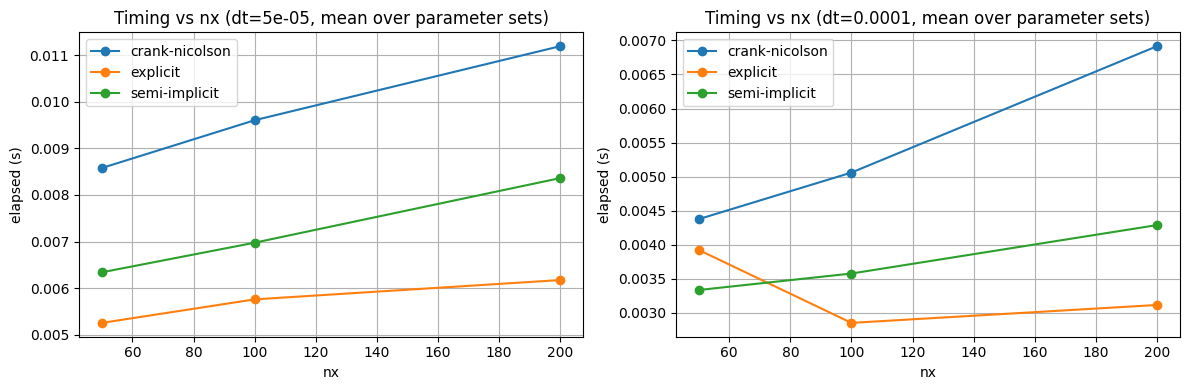

In [3]:
timings = pd.read_csv(OUT / "timings.csv")
dt_values = sorted(timings["dt"].unique())

fig, axes = plt.subplots(1, len(dt_values), figsize=(6 * len(dt_values), 4))
if len(dt_values) == 1:
    axes = [axes]
for ax, dt in zip(axes, dt_values):
    agg = timings[timings["dt"] == dt].groupby(["solver", "nx"])["elapsed"].mean().reset_index()
    for solver, g in agg.groupby("solver"):
        ax.plot(g["nx"], g["elapsed"], marker="o", linestyle="-", label=solver)
    ax.set_xlabel("nx")
    ax.set_ylabel("elapsed (s)")
    ax.set_title(f"Timing vs nx (dt={dt:g}, mean over parameter sets)")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig(OUT / "timings.png")
plt.show()


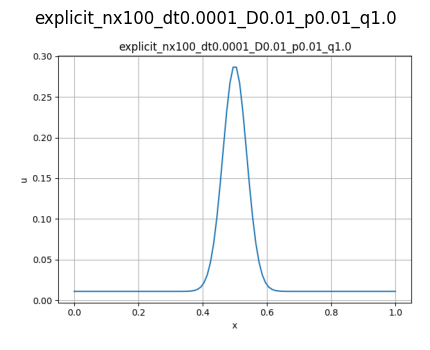

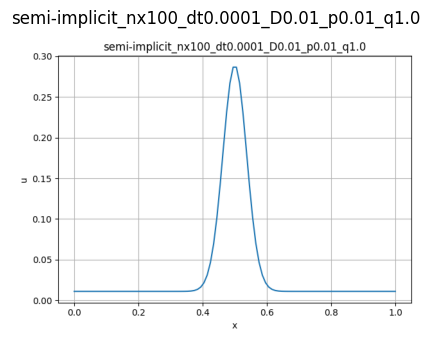

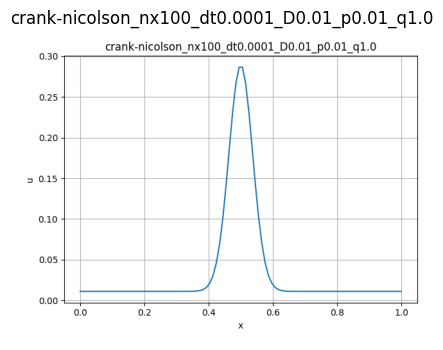

In [4]:
for solver in SOLVERS:
    name = f"{solver}_nx100_dt0.0001_D0.01_p0.01_q1.0"
    img = plt.imread(OUT / f"{name}.png")
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)
    plt.show()
